# PM2.5 next-hour forecasting — EDA on the **new** data

**Team overfitters.** Companion to [`new data/migration.md`](../../new%20data/migration.md) and
[`plan v3 changed/`](../../plan%20v3%20changed/). The earlier walkthrough in
[`notebooks/eda/`](../eda/01_eda_walkthrough.ipynb) analysed the *old* files and is now
partly obsolete — this notebook redoes that analysis for the data we actually have.

## What changed, in one line

**`current_PM2_5` has been deleted from both the training and test files.** Everything else is
byte-for-byte identical to the old data (verified by direct diff — same rows, same ids, same
values in every other column).

## Why that matters so much

In the old data, `current_PM2_5` alone correlated with the answer at **r = 0.968**. You could
score RMSE 19.67 by literally guessing "next hour = this hour" and doing nothing else. That
trick is gone. There is no anchor, no persistence baseline, and no way to compute one.

So the question this notebook answers is: **with the easy answer removed, what signal is
actually left, and where is it?**

## The new numbers to beat

| baseline (no feature engineering) | RMSE |
|---|---:|
| Ridge | 31.99 |
| **LightGBM** | **27.60** |

The old 19.67 / 19.7 figures belong to a different, much easier problem — they are not
comparable and should not be quoted again.

## Ground rules (unchanged)

Backward-looking operations only: no negative shifts, no centred windows, no backfills, no
external data. One section below (§11) deliberately reconstructs the deleted column **for
diagnosis only** — it is clearly marked and must never become a model feature. Figures are
written to `reports/figures/eda_v2/`.

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap


def find_root(p: Path) -> Path:
    """Walk up until we find the repo root (works however the notebook is launched)."""
    for cand in [p, *p.parents]:
        if (cand / "PROJECT.md").exists():
            return cand
    return p


ROOT = find_root(Path.cwd())
NEWDATA = ROOT / "new data"
FIGS = ROOT / "reports" / "figures" / "eda_v2"
FIGS.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 140, "figure.autolayout": True,
    "axes.edgecolor": "#9aa7b4", "grid.color": "#dfe4e9", "grid.linewidth": 0.7,
})

# --- palette -----------------------------------------------------------------
# INK / MUTED are ink + context tokens (text, single series, reference lines).
# Multi-series identity uses a CVD-validated categorical set; correlations use a
# diverging blue<->red with a neutral gray midpoint (never a rainbow).
INK = "#22303f"       # primary single series / ink
MUTED = "#9aa7b4"     # context, reference lines
POS = "#e34948"       # positive / "goes up"
NEG = "#2a78d6"       # negative / "goes down"
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]  # validated, adjacent-safe

DIVERGING = LinearSegmentedColormap.from_list("div_br", [NEG, "#f0efec", POS])
SEQ = LinearSegmentedColormap.from_list("seq_blue", ["#e8f1fd", "#0d366b"])


def save(fig, name: str) -> None:
    fig.savefig(FIGS / f"{name}.png", bbox_inches="tight")


print("root:", ROOT)

root: /Users/keithandre/Documents/GitHub/overfitters


## 2. Load the new data

`new data/*.csv` are read-only competition inputs.

In [2]:
train = pd.read_csv(NEWDATA / "train_new.csv", parse_dates=["observation_timestamp"])
test = pd.read_csv(NEWDATA / "test_new.csv", parse_dates=["observation_timestamp"])

TARGET = "PM2_5_next_hour"
POLL = ["PM10", "SO2", "NO2", "CO", "O3"]          # PM2.5 is NOT in this list any more
METEO = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
FEATURES = POLL + METEO

for df in (train, test):
    df.sort_values(["station", "observation_timestamp"], inplace=True)
    df.reset_index(drop=True, inplace=True)

print(f"train {train.shape[0]:,} rows x {train.shape[1]} cols   "
      f"{train.observation_timestamp.min():%Y-%m-%d} -> {train.observation_timestamp.max():%Y-%m-%d}")
print(f"test  {test.shape[0]:,} rows x {test.shape[1]} cols   "
      f"{test.observation_timestamp.min():%Y-%m-%d} -> {test.observation_timestamp.max():%Y-%m-%d}")
print()
print("current_PM2_5 present in train? ", "current_PM2_5" in train.columns)
print("current_PM2_5 present in test?  ", "current_PM2_5" in test.columns)
print()
print("columns:", list(train.columns))

train 360,954 rows x 19 cols   2013-03-01 -> 2016-08-31
test  51,063 rows x 18 cols   2016-08-31 -> 2017-02-28

current_PM2_5 present in train?  False
current_PM2_5 present in test?   False

columns: ['id', 'observation_timestamp', 'station', 'year', 'month', 'day', 'hour', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'PM2_5_next_hour']


## 3. What we can actually use

The predictors fall into three groups. Nothing here is PM2.5 — that is the whole point.

| group | columns | what it tells us |
|---|---|---|
| **other pollutants** | PM10, SO2, NO2, CO, O3 | how dirty the air is right now, measured other ways |
| **weather** | TEMP, PRES, DEWP, RAIN, WSPM, wd | conditions that disperse or trap pollution |
| **identity / time** | station, year, month, day, hour | where and when |

The obvious first question: **how much does each of these actually tell us about the answer?**

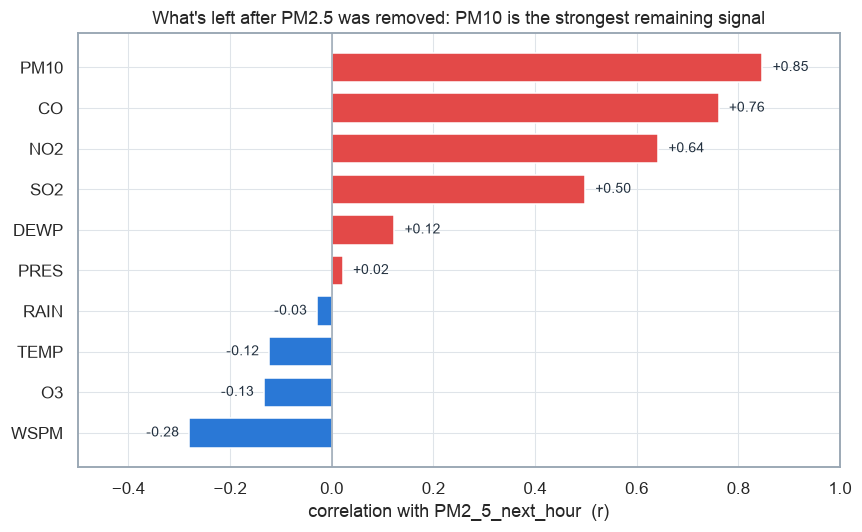

PM10    0.848
CO      0.762
NO2     0.643
SO2     0.499
WSPM   -0.280
O3     -0.133
DEWP    0.124
TEMP   -0.122
RAIN   -0.028
PRES    0.022


In [3]:
corr_target = (
    train[FEATURES + [TARGET]].corr(numeric_only=True)[TARGET]
    .drop(TARGET).sort_values()
)

fig, ax = plt.subplots(figsize=(8, 5))
colors = [POS if v > 0 else NEG for v in corr_target]
ax.barh(corr_target.index, corr_target.to_numpy(), color=colors, height=0.72)
ax.axvline(0, color=MUTED, lw=1)
for name, v in corr_target.items():
    ax.text(v + (0.02 if v > 0 else -0.02), name, f"{v:+.2f}",
            va="center", ha="left" if v > 0 else "right", fontsize=9, color=INK)
ax.set(xlabel="correlation with PM2_5_next_hour  (r)", xlim=(-0.5, 1.0),
       title="What's left after PM2.5 was removed: PM10 is the strongest remaining signal")
ax.set_ylabel("")
save(fig, "01_signal_ranking")
plt.show()

print(corr_target.sort_values(key=abs, ascending=False).round(3).to_string())

### In simple terms

**PM10 is the new best friend.** At r = 0.85 it is far ahead of everything else. That makes
physical sense: PM10 is *coarse* particulate matter and PM2.5 is the *fine* fraction of the very
same dust — they are two measurements of largely the same thing, so when one is high the other
usually is too.

After that: **CO (0.76)** and **NO2 (0.64)** — combustion tracers, so they rise when traffic and
heating pump out particles. **SO2 (0.50)** — coal burning. The weather columns are weak on their
own (all under 0.3), but that does not make them useless: their job is usually to *modify* the
others (wind disperses, humidity traps), which is an effect a straight correlation cannot see.

**Important perspective:** the deleted `current_PM2_5` scored **0.97** on this same scale.
Nothing left comes close. That single number is the whole reason the baseline RMSE jumped from
~19.7 to ~27.6.

## 4. How the remaining pollutants relate to each other

If PM10, CO and NO2 all say roughly the same thing, then having all three is worth less than
it looks. This matters especially for a linear model like Ridge, which struggles when its
inputs overlap heavily.

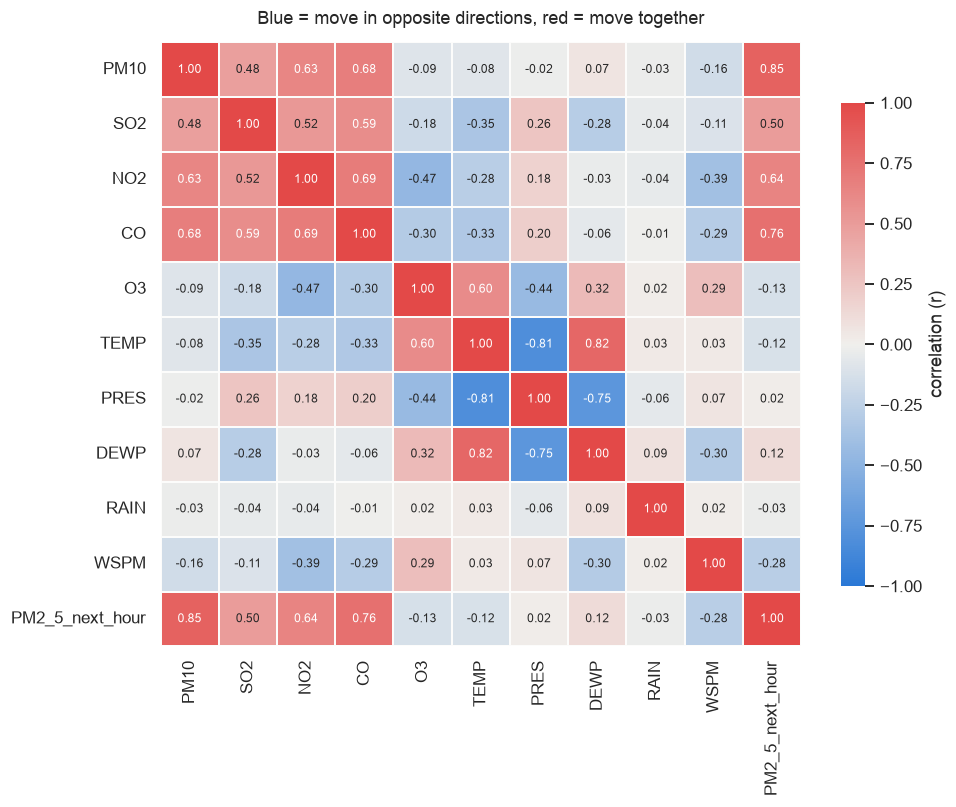

In [4]:
cm = train[FEATURES + [TARGET]].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(cm, cmap=DIVERGING, vmin=-1, vmax=1, center=0, annot=True, fmt=".2f",
            annot_kws={"size": 8}, linewidths=1.2, linecolor="#fcfcfb",
            cbar_kws={"label": "correlation (r)", "shrink": 0.8}, ax=ax)
ax.set_title("Blue = move in opposite directions, red = move together", pad=12)
save(fig, "02_correlation_matrix")
plt.show()

### In simple terms

Look at the red block in the top-left: **PM10, CO and NO2 are all fairly correlated with each
other (0.63–0.69)**, because they all rise during the same polluted, stagnant conditions. So
they are partly telling us the same story three times.

The useful exception is **O3 (ozone)**, which is *negatively* related to the others (blue). Ozone
forms in sunny, clean, well-mixed air — the opposite conditions to a pollution build-up. So it
carries genuinely *different* information rather than a repeat, which makes it more valuable to
a model than its weak standalone correlation (−0.13) suggests.

The weather block bottom-right also shows the strong TEMP–DEWP (0.82) and TEMP–PRES (−0.81)
relationships, which are just normal physics, not signal about pollution.

## 5. PM10 as the new "quasi-anchor"

Since PM10 is doing the job `current_PM2_5` used to do, it is worth looking at that relationship
closely. Two views: the raw scatter (as a density plot, since 360k points would be a black
blob), and the average answer for each PM10 level.

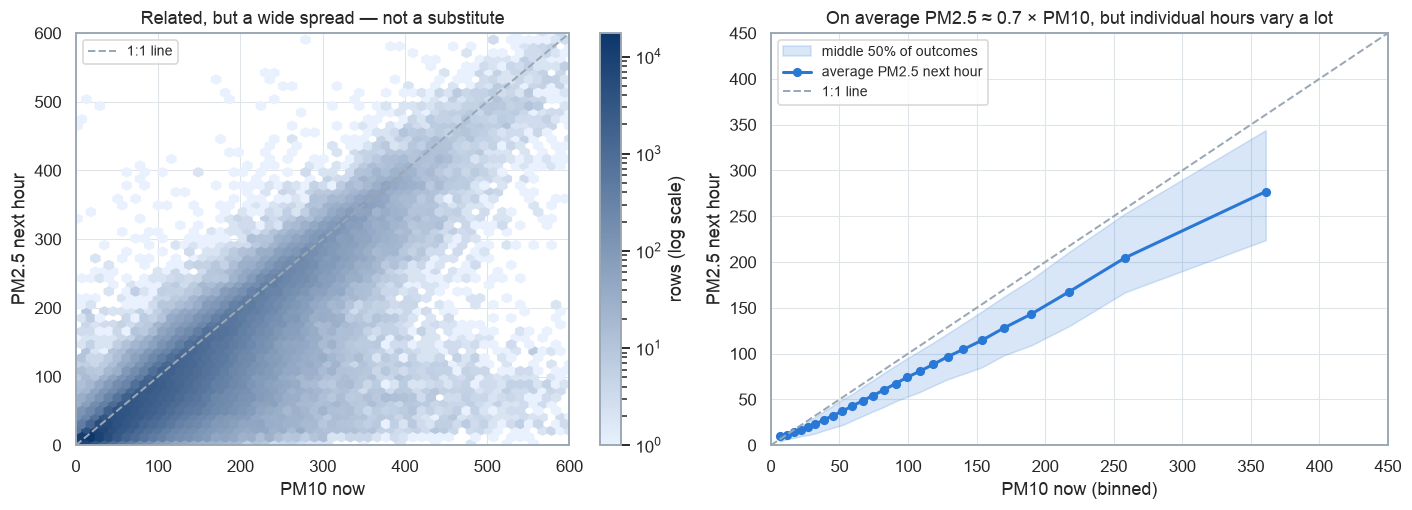

correlation PM10 vs target: 0.860
median ratio PM2.5 / PM10 : 0.768


In [5]:
sub = train[["PM10", TARGET]].dropna()
sub = sub[(sub.PM10 <= 600) & (sub[TARGET] <= 600)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

hb = axes[0].hexbin(sub.PM10, sub[TARGET], gridsize=55, cmap=SEQ, bins="log", mincnt=1)
lim = [0, 600]
axes[0].plot(lim, lim, color=MUTED, ls="--", lw=1.3, label="1:1 line")
axes[0].set(xlabel="PM10 now", ylabel="PM2.5 next hour", xlim=lim, ylim=lim,
            title="Related, but a wide spread — not a substitute")
axes[0].legend(loc="upper left", fontsize=9)
fig.colorbar(hb, ax=axes[0], label="rows (log scale)")

bins = pd.qcut(sub.PM10, 25, duplicates="drop")
b = sub.groupby(bins, observed=True).agg(pm10=("PM10", "mean"), y=(TARGET, "mean"),
                                         lo=(TARGET, lambda s: s.quantile(0.25)),
                                         hi=(TARGET, lambda s: s.quantile(0.75)))
axes[1].fill_between(b.pm10, b.lo, b.hi, color=NEG, alpha=0.18, label="middle 50% of outcomes")
axes[1].plot(b.pm10, b.y, color=NEG, lw=2, marker="o", ms=5, label="average PM2.5 next hour")
axes[1].plot(lim, lim, color=MUTED, ls="--", lw=1.3, label="1:1 line")
axes[1].set(xlabel="PM10 now (binned)", ylabel="PM2.5 next hour", xlim=[0, 450], ylim=[0, 450],
            title="On average PM2.5 ≈ 0.7 × PM10, but individual hours vary a lot")
axes[1].legend(loc="upper left", fontsize=9)

save(fig, "03_pm10_quasi_anchor")
plt.show()

r = sub.PM10.corr(sub[TARGET])
ratio = (train[TARGET] / train.PM10.replace(0, np.nan)).median()
print(f"correlation PM10 vs target: {r:.3f}")
print(f"median ratio PM2.5 / PM10 : {ratio:.3f}")

### In simple terms

The left panel shows the relationship is real but **loose**. If PM10 were a perfect stand-in,
every point would sit on a tight line. Instead there is a wide cloud: for a given PM10 reading,
next-hour PM2.5 could plausibly be half or double the typical value.

The right panel shows the *average* relationship is well-behaved and roughly proportional —
PM2.5 tends to be about **0.7×** PM10 — but the shaded band (the middle 50% of actual outcomes)
is wide, and gets wider as pollution rises.

**What this means for modelling:** PM10 gives you a decent starting estimate, and the model's
real job is to correct that estimate using everything else — which is exactly the "proxy anchor"
idea in [plan 03](../../plan%20v3%20changed/03-proxy-anchor-residual.md).

## 6. The target, and where the error will come from

RMSE punishes big misses far more than small ones (errors are squared). So it is worth knowing
how lopsided this target is.

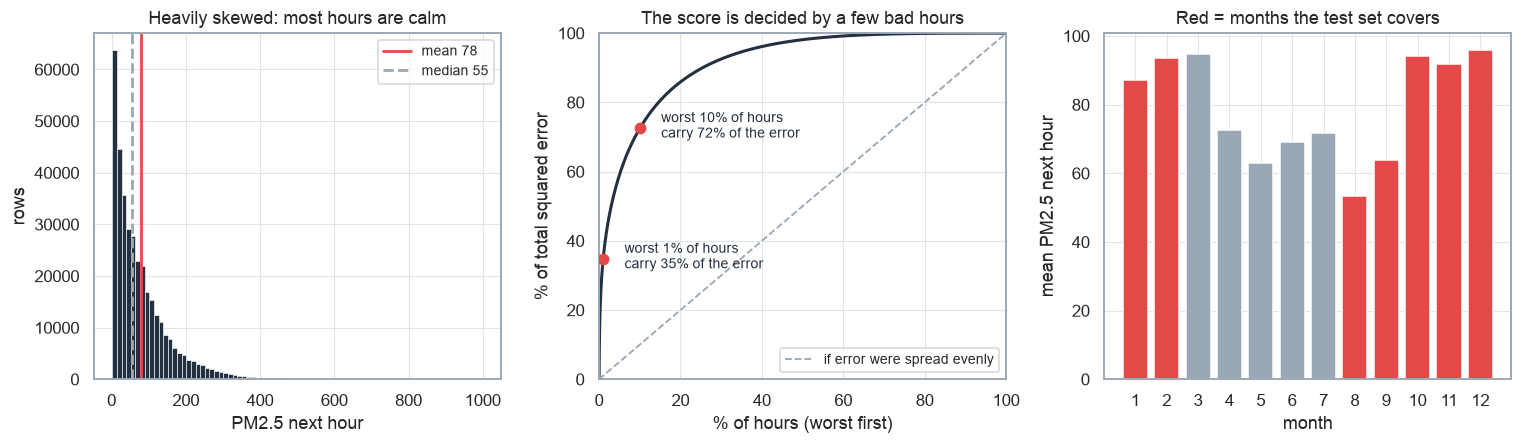

target: mean 78.0  median 55  p95 235  max 999
worst 1% of hours carry 34.7% of squared error
worst 10% of hours carry 72.5% of squared error


In [6]:
y = train[TARGET].dropna()

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

axes[0].hist(y, bins=80, color=INK, edgecolor="white", linewidth=0.4)
axes[0].axvline(y.mean(), color=POS, lw=1.8, label=f"mean {y.mean():.0f}")
axes[0].axvline(y.median(), color=MUTED, lw=1.8, ls="--", label=f"median {y.median():.0f}")
axes[0].set(xlabel="PM2.5 next hour", ylabel="rows", title="Heavily skewed: most hours are calm")
axes[0].legend(fontsize=9)

# error concentration for a simple PM10-only prediction (illustrative baseline)
d = train[["PM10", TARGET]].dropna()
slope = (d.PM10 * d[TARGET]).sum() / (d.PM10 ** 2).sum()
se = ((d[TARGET] - slope * d.PM10) ** 2).sort_values(ascending=False).to_numpy()
frac_rows = np.arange(1, len(se) + 1) / len(se)
frac_err = se.cumsum() / se.sum()
axes[1].plot(frac_rows * 100, frac_err * 100, color=INK, lw=2)
axes[1].plot([0, 100], [0, 100], color=MUTED, ls="--", lw=1.2, label="if error were spread evenly")
for pct in (1, 10):
    v = frac_err[int(len(se) * pct / 100) - 1] * 100
    axes[1].scatter([pct], [v], color=POS, zorder=5, s=45)
    axes[1].annotate(f"worst {pct}% of hours\ncarry {v:.0f}% of the error",
                     (pct, v), textcoords="offset points", xytext=(14, -6),
                     fontsize=9, color=INK)
axes[1].set(xlabel="% of hours (worst first)", ylabel="% of total squared error",
            xlim=(0, 100), ylim=(0, 100), title="The score is decided by a few bad hours")
axes[1].legend(loc="lower right", fontsize=9)

by_month = train.groupby("month")[TARGET].mean()
test_months = sorted(test.month.unique())
axes[2].bar(by_month.index, by_month.to_numpy(),
            color=[POS if m in test_months else MUTED for m in by_month.index])
axes[2].set(xlabel="month", ylabel="mean PM2.5 next hour", xticks=range(1, 13),
            title="Red = months the test set covers")

save(fig, "04_target_and_error")
plt.show()

print(f"target: mean {y.mean():.1f}  median {y.median():.0f}  p95 {y.quantile(.95):.0f}  max {y.max():.0f}")
print(f"worst 1% of hours carry {frac_err[int(len(se)*.01)-1]:.1%} of squared error")
print(f"worst 10% of hours carry {frac_err[int(len(se)*.10)-1]:.1%} of squared error")

### In simple terms

**Left:** most hours are fairly clean (median ~55) but there is a long tail stretching past 900.
The average is dragged well above the median by those rare severe hours.

**Middle:** this is the single most important chart for strategy. Using a simple PM10-based
guess, the **worst 1% of hours cause roughly a third of all the error**, and the worst 10% cause
about three quarters. Getting calm hours slightly better is nearly worthless; getting severe
hours less wrong is where the score is won.

**Right:** the test set covers September–February — the heating season, which is both more
polluted and more volatile. Validation that averages over spring and summer will look better
than reality.

## 7. Missing values

Missing data has to be handled, and the rates differ between train and test — which matters,
because a feature that is usually present in training but often missing in the test set is a
trap.

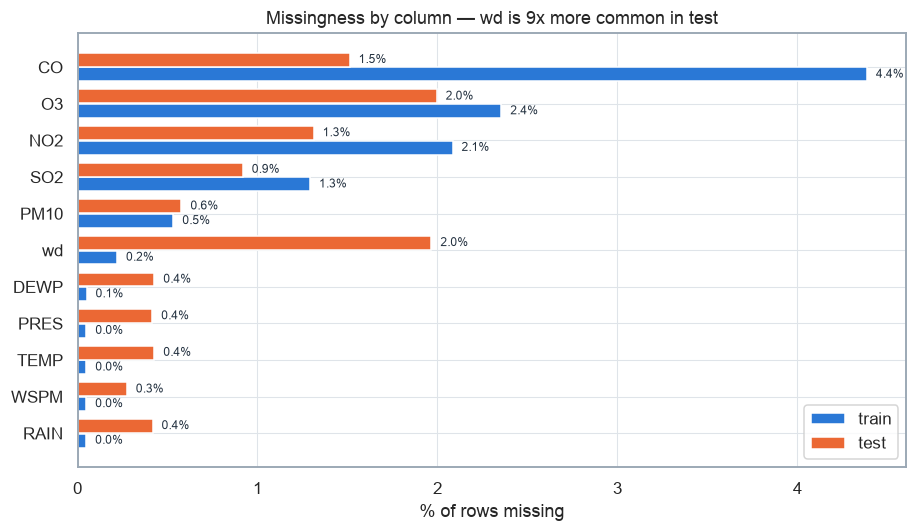

      train  test
RAIN   0.05  0.42
WSPM   0.05  0.27
TEMP   0.05  0.43
PRES   0.05  0.42
DEWP   0.05  0.43
wd     0.22  1.97
PM10   0.53  0.58
SO2    1.29  0.92
NO2    2.08  1.31
O3     2.35  2.00
CO     4.39  1.51


In [7]:
miss = pd.DataFrame({
    "train": train[FEATURES + ["wd"]].isna().mean() * 100,
    "test": test[FEATURES + ["wd"]].isna().mean() * 100,
}).sort_values("train", ascending=True)

fig, ax = plt.subplots(figsize=(8.5, 5))
ypos = np.arange(len(miss))
ax.barh(ypos - 0.2, miss["train"], height=0.38, color=CAT[0], label="train")
ax.barh(ypos + 0.2, miss["test"], height=0.38, color=CAT[1], label="test")
for i, (tr_v, te_v) in enumerate(zip(miss["train"], miss["test"])):
    ax.text(tr_v + 0.05, i - 0.2, f"{tr_v:.1f}%", va="center", fontsize=8, color=INK)
    ax.text(te_v + 0.05, i + 0.2, f"{te_v:.1f}%", va="center", fontsize=8, color=INK)
ax.set(yticks=ypos, yticklabels=miss.index, xlabel="% of rows missing",
       title="Missingness by column — wd is 9x more common in test")
ax.legend(loc="lower right")
save(fig, "05_missingness")
plt.show()

print(miss.round(2).to_string())

### In simple terms

Missingness is low overall (mostly under 5%), so this is a manageable problem rather than a
crisis. Two things worth remembering:

- **CO is the most-missing column in training (4.4%)** but much less so in test (1.5%).
- **Wind direction (`wd`) is missing 9× more often in test (2.0%) than in train (0.2%).** Blank
  wind direction should be treated as its own category, never filled in with the most common
  direction — those blank rows are genuinely different, and there are far more of them in the
  data we will be scored on.

## 8. Do the stations move together?

In the old data, the strongest single feature we ever found was *"how much did the other
stations' PM2.5 change in the last hour"* — pollution arrives across the city as a front, so
neighbours give early warning. PM2.5 is gone, but **PM10, CO and NO2 are still measured at every
station every hour**, so the same idea should transfer. This section checks whether it holds.

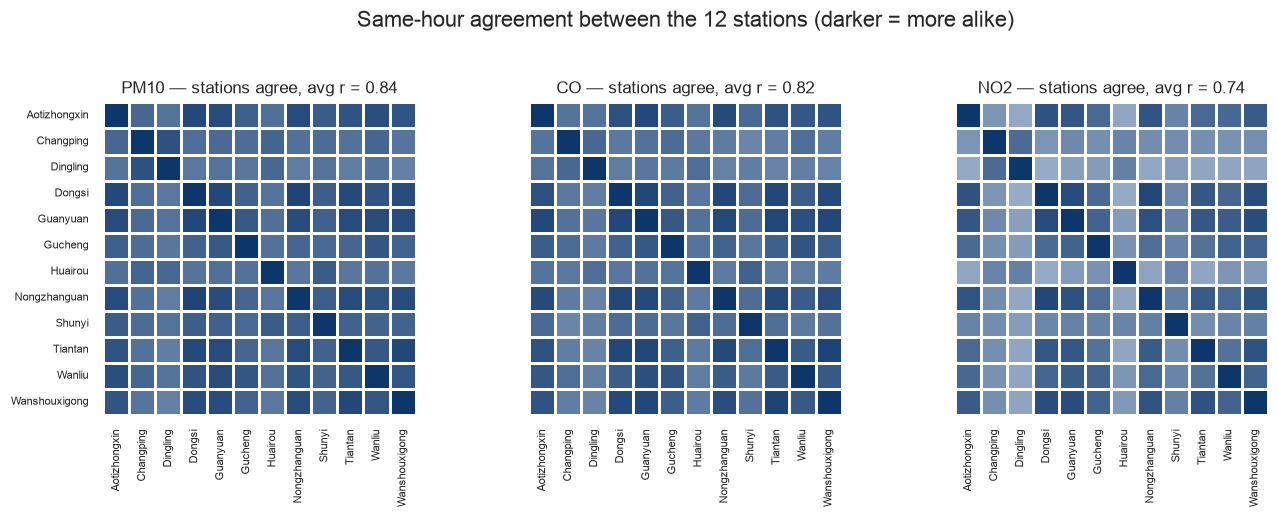

In [8]:
def station_corr(col: str) -> pd.DataFrame:
    wide = train.pivot_table(index="observation_timestamp", columns="station", values=col)
    return wide.corr()


fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, col in zip(axes, ["PM10", "CO", "NO2"]):
    c = station_corr(col)
    off = c.to_numpy()[~np.eye(len(c), dtype=bool)]
    sns.heatmap(c, cmap=SEQ, vmin=0.3, vmax=1, square=True, cbar=False,
                xticklabels=True, yticklabels=(col == "PM10"), ax=ax,
                linewidths=0.8, linecolor="#fcfcfb")
    ax.set_title(f"{col} — stations agree, avg r = {off.mean():.2f}", fontsize=11)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)
fig.suptitle("Same-hour agreement between the 12 stations (darker = more alike)", y=1.02)
save(fig, "06_cross_station_levels")
plt.show()

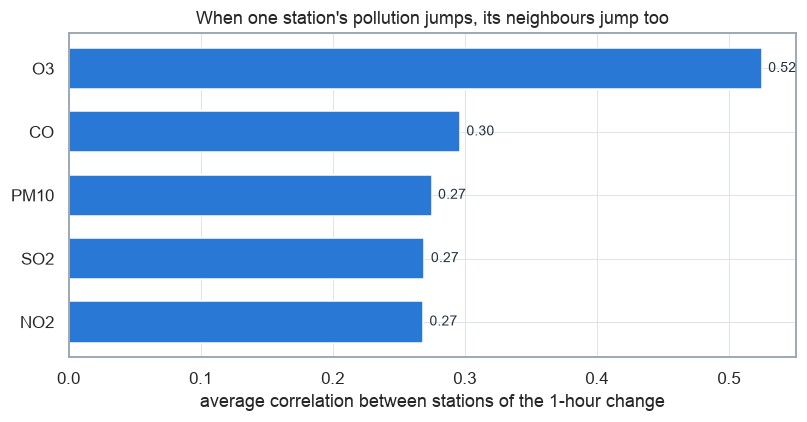

NO2     0.268
SO2     0.269
PM10    0.275
CO      0.296
O3      0.525


In [9]:
# Do the *changes* move together too? That is what makes neighbours an early warning.
chg_corr = {}
for col in ["PM10", "CO", "NO2", "SO2", "O3"]:
    wide = train.pivot_table(index="observation_timestamp", columns="station", values=col)
    d = wide.diff()                      # backward difference only
    c = d.corr().to_numpy()
    chg_corr[col] = c[~np.eye(c.shape[0], dtype=bool)].mean()

s = pd.Series(chg_corr).sort_values()
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.barh(s.index, s.to_numpy(), color=CAT[0], height=0.65)
for name, v in s.items():
    ax.text(v + 0.005, name, f"{v:.2f}", va="center", fontsize=9, color=INK)
ax.set(xlabel="average correlation between stations of the 1-hour change",
       title="When one station's pollution jumps, its neighbours jump too")
save(fig, "07_cross_station_momentum")
plt.show()
print(s.round(3).to_string())

### In simple terms

**The levels agree strongly** (first chart): when one station is dirty, they all tend to be
dirty — average agreement across the 12 stations is 0.84 for PM10, 0.82 for CO, 0.89 for O3.
That is a city-wide weather effect, not 12 independent places.

**The *changes* agree too, but more weakly** (second chart). The hour-to-hour jumps correlate
0.28 for PM10 and 0.30 for CO across stations — real, but much looser than the levels. O3 is the
strongest at 0.53, because ozone is driven by sunlight, which arrives everywhere at once.

That gap between 0.84 (levels) and 0.28 (changes) is the honest picture: neighbours tell you
reliably *how dirty the city is*, and only weakly *which way it is about to move*. The neighbour
signal is still worth building — a 0.28 correlation on the hard part of the problem is not
nothing — but §10 shows it should be expected to help modestly, not transform the score.

## 9. How far back is worth looking?

If we build "what was this value an hour ago / three hours ago" features, how far back do they
stay useful?

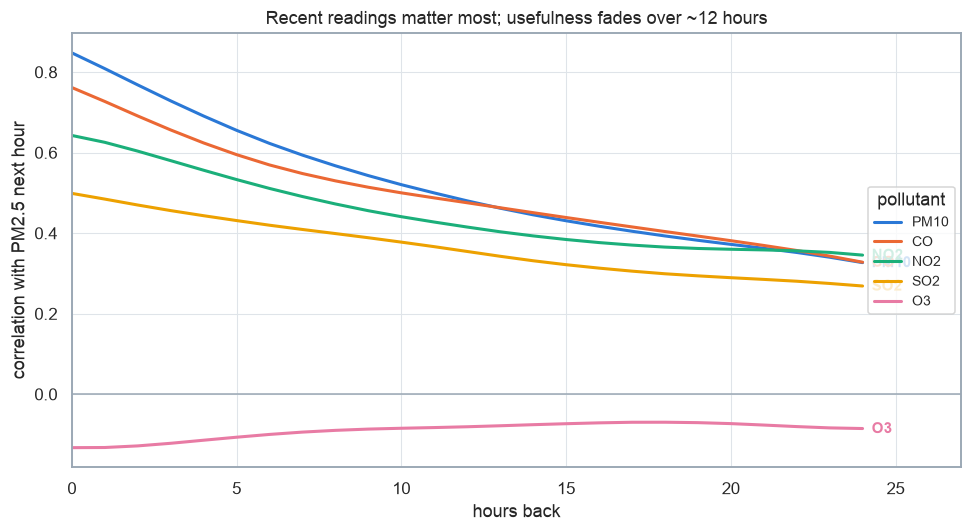

col     CO    NO2     O3   PM10    SO2
lag                                   
0    0.762  0.643 -0.133  0.848  0.499
1    0.727  0.626 -0.132  0.809  0.485
3    0.656  0.580 -0.122  0.728  0.456
6    0.569  0.511 -0.100  0.623  0.420
12   0.475  0.415 -0.081  0.480  0.354
24   0.328  0.345 -0.085  0.327  0.269


In [10]:
LAGS = list(range(0, 25))
rows = []
tr = train.sort_values(["station", "observation_timestamp"])
g = tr.groupby("station", sort=False)
for col in ["PM10", "CO", "NO2", "SO2", "O3"]:
    for k in LAGS:
        rows.append({"col": col, "lag": k, "r": g[col].shift(k).corr(tr[TARGET])})
lagdf = pd.DataFrame(rows).pivot(index="lag", columns="col", values="r")

fig, ax = plt.subplots(figsize=(9, 5))
for i, col in enumerate(["PM10", "CO", "NO2", "SO2", "O3"]):
    ax.plot(lagdf.index, lagdf[col], color=CAT[i], lw=2, label=col)
    ax.annotate(col, (lagdf.index[-1], lagdf[col].iloc[-1]), color=CAT[i],
                fontsize=10, fontweight="bold", xytext=(6, -3), textcoords="offset points")
ax.axhline(0, color=MUTED, lw=1)
ax.set(xlabel="hours back", ylabel="correlation with PM2.5 next hour",
       xlim=(0, 27), title="Recent readings matter most; usefulness fades over ~12 hours")
ax.legend(loc="center right", fontsize=9, title="pollutant")
save(fig, "08_lag_structure")
plt.show()
print(lagdf.loc[[0, 1, 3, 6, 12, 24]].round(3).to_string())

### In simple terms

Every line starts highest at lag 0 (the reading right now) and decays as we look further back.
The decay is steady rather than sudden — **PM10 falls from 0.85 now to 0.62 at six hours and
0.33 at a day old.**

Interestingly, **NO2 decays the most slowly in relative terms** (0.64 → 0.35 at 24h, keeping 54%
of its signal, versus PM10 keeping 39%), because traffic follows a strong daily rhythm that
repeats at the same hour each day.

The practical read: **lags of 1, 3, 6, 12 and 24 hours are all worth building.** There is little
point going far beyond a day — by then every pollutant has lost most of its signal, and each
extra feature adds noise and training time.

## 10. Motion: does *change* predict better than *level*?

This was the biggest lesson from the old data — knowing how a value is **moving** beat knowing
what it **is**. Let's test whether that still holds now.

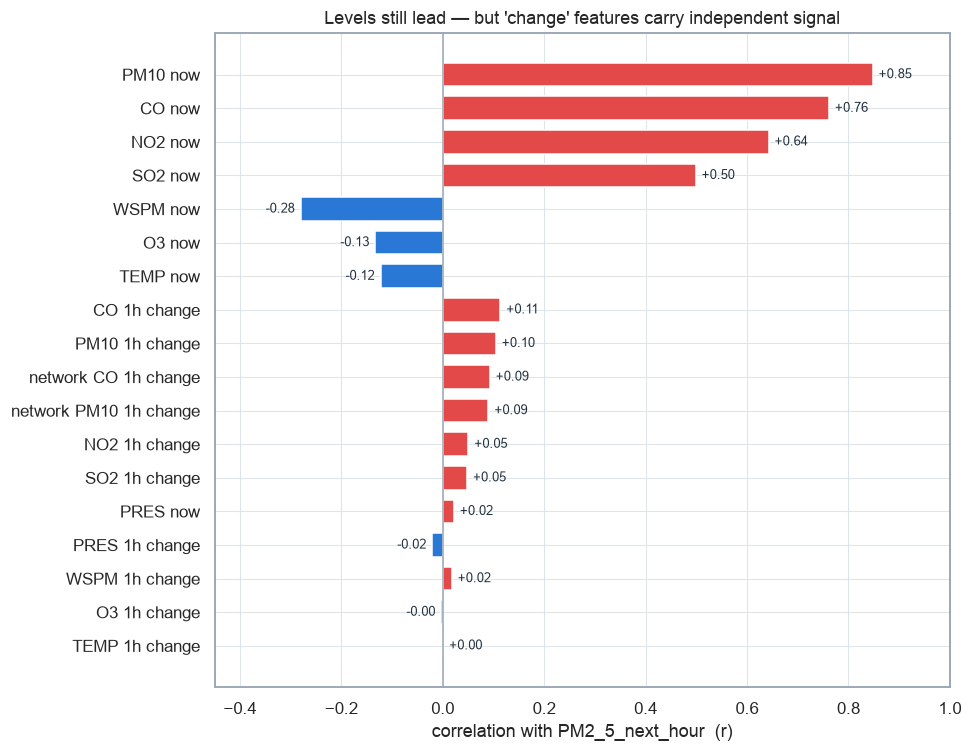

PM10 now                  0.848
CO now                    0.762
NO2 now                   0.643
SO2 now                   0.499
WSPM now                 -0.280
O3 now                   -0.133
TEMP now                 -0.122
CO 1h change              0.114
PM10 1h change            0.105
network CO 1h change      0.093
network PM10 1h change    0.090
NO2 1h change             0.050
SO2 1h change             0.048
PRES now                  0.022
PRES 1h change           -0.021
WSPM 1h change            0.018
O3 1h change             -0.003
TEMP 1h change            0.001


In [11]:
tr = train.sort_values(["station", "observation_timestamp"]).copy()
g = tr.groupby("station", sort=False)

feat = {}
for col in ["PM10", "CO", "NO2", "SO2", "O3", "WSPM", "TEMP", "PRES"]:
    feat[f"{col} now"] = tr[col]
    feat[f"{col} 1h change"] = tr[col] - g[col].shift(1)

# network momentum: how much the OTHER stations' PM10 / CO moved in the last hour
for col in ["PM10", "CO"]:
    ch = tr[col] - g[col].shift(1)
    tmp = tr[["observation_timestamp"]].assign(ch=ch)
    tot = tmp.groupby("observation_timestamp")["ch"].transform("sum")
    cnt = tmp.groupby("observation_timestamp")["ch"].transform("count")
    feat[f"network {col} 1h change"] = (tot - ch.fillna(0)) / (cnt - ch.notna()).replace(0, np.nan)

F = pd.DataFrame(feat)
sig = F.corrwith(tr[TARGET]).dropna().sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
top = sig.head(18)[::-1]
colors = [POS if v > 0 else NEG for v in top]
ax.barh(top.index, top.to_numpy(), color=colors, height=0.7)
ax.axvline(0, color=MUTED, lw=1)
for name, v in top.items():
    ax.text(v + (0.012 if v > 0 else -0.012), name, f"{v:+.2f}", va="center",
            ha="left" if v > 0 else "right", fontsize=8.5, color=INK)
ax.set(xlabel="correlation with PM2_5_next_hour  (r)", xlim=(-0.45, 1.0),
       title="Levels still lead — but 'change' features carry independent signal")
ax.set_ylabel("")
save(fig, "09_motion_features")
plt.show()
print(sig.round(3).to_string())

### In simple terms

Here the new data behaves **differently from the old data**, and the difference is important.

In the old data, raw levels were nearly useless for what we had to predict, because
`current_PM2_5` already explained the level and only the *change* was left to guess — so motion
features dominated. Now there is no anchor, so we are predicting the **whole level from
scratch**, and the raw levels (PM10 0.85, CO 0.76, NO2 0.64) lead the ranking by a wide margin.

**The change features are much weaker than they were last time.** The best of them —
`CO 1h change` at 0.11 and `PM10 1h change` at 0.11 — are roughly a *third* of the strength that
PM2.5's own motion features reached in the old data (up to 0.33). The network-momentum versions
land just behind at 0.09. That is a genuine, measured disappointment relative to the hope in
[plan 02](../../plan%20v3%20changed/02-copollutant-motion-features.md), and it should temper
expectations there.

**But weak is not worthless, for a specific reason:** these features measure something the
levels physically cannot — *direction of travel*. A PM10 of 150 that has been climbing fast is a
different situation from a PM10 of 150 that is falling, and no level feature can separate those
two. A tree model can use that as a conditional correction even when its standalone correlation
is small.

**Conclusion for modelling:** build both, but flip the old priority. Levels are the backbone
this time; motion is a secondary correction expected to be worth a modest amount, not the
headline win it was last round.

## 11. Diagnostic only — what exactly was taken away

> ⚠️ **This section reconstructs the deleted column for understanding only. These values must
> never be used as model features.** The reason is in
> [`new data/migration.md` §4](../../new%20data/migration.md): a row's target is exactly the
> next row's old `current_PM2_5`, so history can be rebuilt *for training rows* — but not for
> test rows, where the chain breaks immediately. Using it would not generalise, and would
> defeat the purpose of the organisers removing the column.

This is here purely to quantify **how much difficulty was added**.

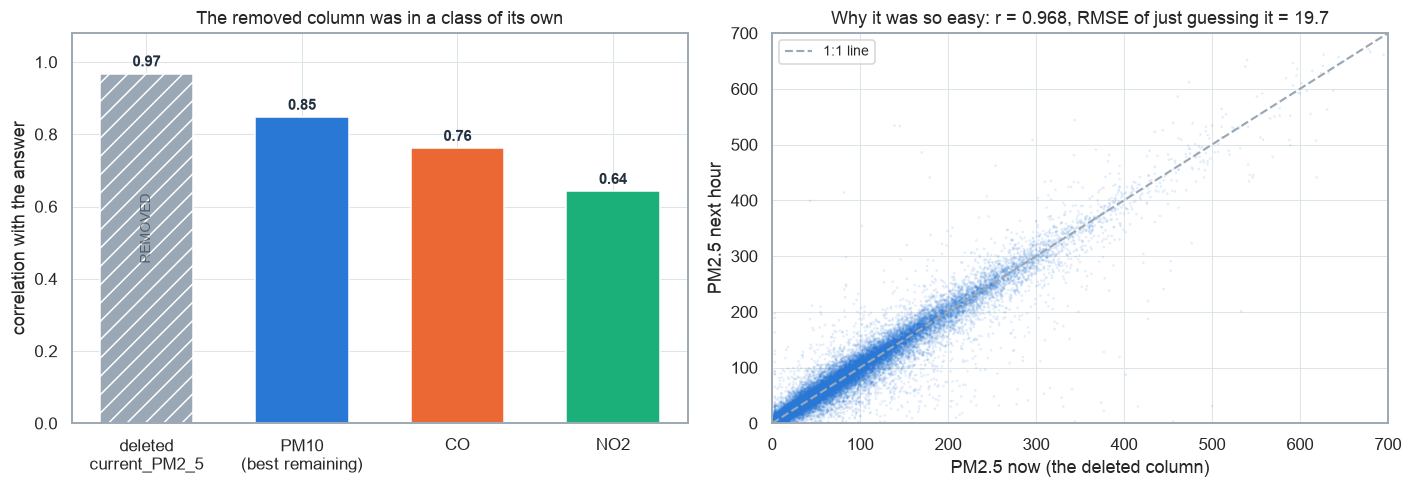

reconstructed anchor vs target : r = 0.9679
'guess it never changes' RMSE  : 19.67   <-- the old easy baseline, now impossible
best remaining single column   : PM10, r = 0.8477


In [12]:
tr = train.sort_values(["station", "observation_timestamp"]).copy()
g = tr.groupby("station", sort=False)
prev_ts = g["observation_timestamp"].shift(1)
contiguous = (tr["observation_timestamp"] - prev_ts) == pd.Timedelta(hours=1)

# the deleted column, rebuilt: PM2.5 now == the PREVIOUS row's target (past info only)
tr["pm25_now_reconstructed"] = g[TARGET].shift(1).where(contiguous)

ok = tr.dropna(subset=["pm25_now_reconstructed", TARGET])
r_anchor = ok["pm25_now_reconstructed"].corr(ok[TARGET])
rmse_persist = np.sqrt(((ok[TARGET] - ok["pm25_now_reconstructed"]) ** 2).mean())
r_pm10 = train["PM10"].corr(train[TARGET])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

names = ["deleted\ncurrent_PM2_5", "PM10\n(best remaining)", "CO", "NO2"]
vals = [r_anchor, r_pm10, train.CO.corr(train[TARGET]), train.NO2.corr(train[TARGET])]
bars = axes[0].bar(names, vals, color=[MUTED, CAT[0], CAT[1], CAT[2]], width=0.6)
bars[0].set_hatch("//")
for b, v in zip(bars, vals):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.2f}",
                 ha="center", fontsize=10, color=INK, fontweight="bold")
axes[0].set(ylim=(0, 1.08), ylabel="correlation with the answer",
            title="The removed column was in a class of its own")
axes[0].text(0, 0.45, "REMOVED", ha="center", fontsize=9, color=INK, rotation=90, alpha=.6)

s = ok.sample(40000, random_state=0)
axes[1].scatter(s["pm25_now_reconstructed"], s[TARGET], s=3, alpha=0.12, color=NEG,
                edgecolors="none")
axes[1].plot([0, 700], [0, 700], color=MUTED, ls="--", lw=1.4, label="1:1 line")
axes[1].set(xlim=(0, 700), ylim=(0, 700), xlabel="PM2.5 now (the deleted column)",
            ylabel="PM2.5 next hour",
            title=f"Why it was so easy: r = {r_anchor:.3f}, RMSE of just guessing it = {rmse_persist:.1f}")
axes[1].legend(loc="upper left", fontsize=9)

save(fig, "10_what_was_removed")
plt.show()

print(f"reconstructed anchor vs target : r = {r_anchor:.4f}")
print(f"'guess it never changes' RMSE  : {rmse_persist:.2f}   <-- the old easy baseline, now impossible")
print(f"best remaining single column   : PM10, r = {r_pm10:.4f}")

### In simple terms

The left chart says it all: the deleted column sat at **0.97** while the best thing we have left
sits at **0.85**. That gap does not look enormous, but at these levels it is the difference
between "almost solved" and "genuinely hard" — 0.97 means only ~6% of the variation was left to
explain, while 0.85 leaves ~28%, nearly five times as much.

The right chart shows why the old problem was easy: nearly every point sits on the 1:1 line.
Simply repeating the current reading scored **RMSE ≈ 19.7**. That option no longer exists, which
is precisely why the new baselines are 27.6 (LightGBM) and 32.0 (Ridge).

**This is the honest framing to carry into modelling: a higher RMSE now is not a worse model, it
is a harder question.**

## 12. Weather: the conditions that trap or clear pollution

Weather columns were weak on their own in §3. Here is why they still matter — their effect
shows up in *combination*, and in how they shape the average outcome.

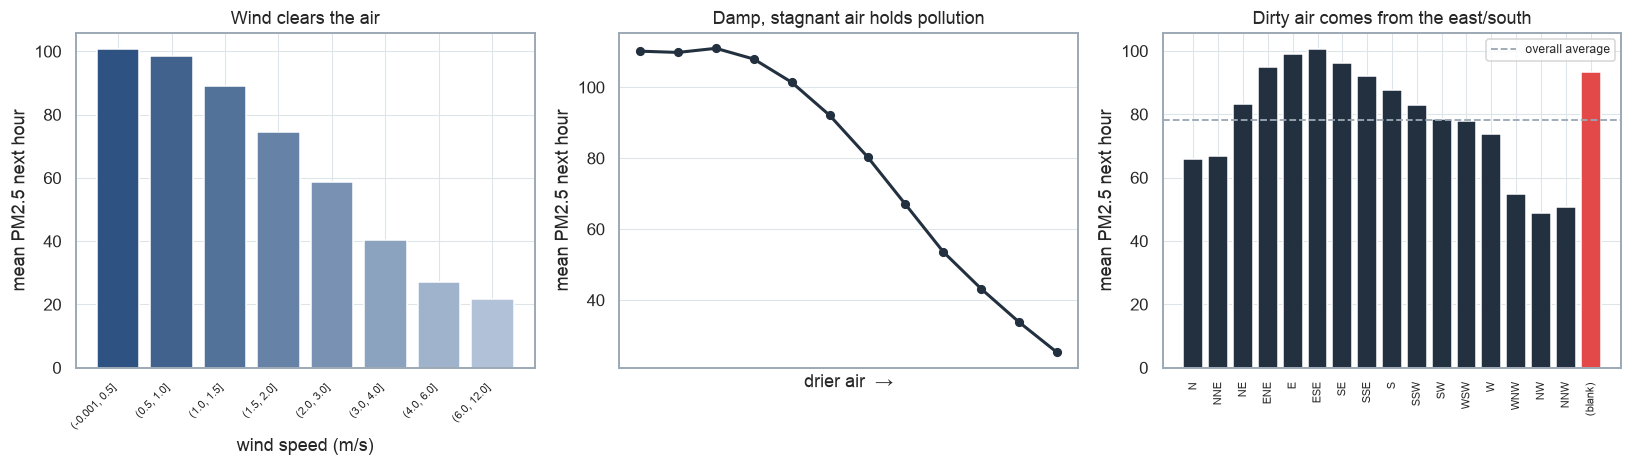

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

wb = pd.cut(train.WSPM, [0, 0.5, 1, 1.5, 2, 3, 4, 6, 12], include_lowest=True)
w = train.groupby(wb, observed=True)[TARGET].mean()
axes[0].bar(range(len(w)), w.to_numpy(), color=SEQ(np.linspace(0.85, 0.25, len(w))))
axes[0].set_xticks(range(len(w)))
axes[0].set_xticklabels([str(i) for i in w.index], rotation=45, ha="right", fontsize=7.5)
axes[0].set(xlabel="wind speed (m/s)", ylabel="mean PM2.5 next hour",
            title="Wind clears the air")

train["_ddep"] = train.TEMP - train.DEWP          # dew-point depression: high = dry air
db = pd.qcut(train["_ddep"], 12, duplicates="drop")
d = train.groupby(db, observed=True)[TARGET].mean()
axes[1].plot(range(len(d)), d.to_numpy(), color=INK, lw=2, marker="o", ms=5)
axes[1].set(xlabel="drier air  →", ylabel="mean PM2.5 next hour",
            title="Damp, stagnant air holds pollution")
axes[1].set_xticks([])

ORDER = ["N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE",
         "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW"]
wd = train.assign(wd_f=train.wd.fillna("(blank)")).groupby("wd_f")[TARGET].mean()
wd = wd.reindex(ORDER + ["(blank)"])
axes[2].bar(range(len(wd)), wd.to_numpy(),
            color=[POS if k == "(blank)" else INK for k in wd.index])
axes[2].axhline(train[TARGET].mean(), color=MUTED, ls="--", lw=1.2, label="overall average")
axes[2].set_xticks(range(len(wd)))
axes[2].set_xticklabels(wd.index, rotation=90, fontsize=7)
axes[2].set(ylabel="mean PM2.5 next hour", title="Dirty air comes from the east/south")
axes[2].legend(fontsize=8)

save(fig, "11_meteorology")
plt.show()

### In simple terms

- **Wind is the cleaner.** Above roughly 2 m/s the average next-hour PM2.5 drops sharply — wind
  physically blows particles away. This is one of the few things that reliably predicts pollution
  going *down*.
- **Humid, still air is the trap.** The middle chart runs from damp air on the left to dry air on
  the right, and pollution falls steadily as air dries out. Damp air lets particles absorb water
  and grow, and usually comes with stagnant conditions.
- **Direction matters.** Easterly and south-easterly winds bring the dirtiest air; north-westerly
  brings the cleanest. And the red `(blank)` bar — the rows with missing wind direction — sits
  *well above* average, confirming those rows are not random and must be kept as their own
  category rather than filled in.

## 13. Summary — what this EDA says to do next

**What changed**

The single most predictive column (`current_PM2_5`, r = 0.968) was removed. The best remaining
column, PM10, sits at r = 0.848. That is why the baseline RMSE moved from ~19.7 to ~27.6, and
**that increase is expected, not a regression.**

**What we have to work with**

| finding | measured | what to do about it |
|---|---|---|
| PM10, CO, NO2 carry most of the signal | r = 0.85 / 0.76 / 0.64 | build the backbone here — levels, lags, rolling averages |
| O3 is *negatively* related to the rest | r = −0.13 vs target, negative against other pollutants | keep it: different information, not a repeat |
| Station **levels** move together strongly | avg r = 0.84 (PM10) | network-level features are reliable |
| Station **changes** move together weakly | avg r = 0.28 (PM10), 0.30 (CO) | neighbour-momentum still worth building, but expect modest gains — not the big win it was last round |
| Motion features are much weaker than before | best 1h-change r = 0.11 vs 0.33 last time | secondary correction, not the headline; **revise [plan 02](../../plan%20v3%20changed/02-copollutant-motion-features.md)'s expectations down** |
| PM10 ≈ a loose proxy for PM2.5 | ratio ~0.77, wide spread | test the proxy-anchor idea ([plan 03](../../plan%20v3%20changed/03-proxy-anchor-residual.md)) — now the more promising of the two |
| Lags fade steadily out to ~24h | PM10 0.85 → 0.33 at 24h | build 1/3/6/12/24h lags; little value beyond a day |
| Worst 1% of hours carry ~35% of squared error | worst 10% carry 73% | judge every change on the severe hours, not the average |
| Test is September–February and more polluted | — | validate on autumn/winter windows only — never a random split |
| `wd` blank 9× more often in test | 0.22% → 1.97% | keep blank as its own category, never fill it in |

**What this changes about the plans**

The EDA shifts the odds between the two main ideas. [Plan 02](../../plan%20v3%20changed/02-copollutant-motion-features.md)
(co-pollutant motion) was written expecting a direct transfer of the old project's biggest win —
the measurements above say that transfer will be **partial at best**, since the co-pollutants'
motion signal is about a third as strong as PM2.5's was. [Plan 03](../../plan%20v3%20changed/03-proxy-anchor-residual.md)
(proxy anchor) now looks like the better bet: PM10 at 0.85 is a genuinely strong base to build a
correction on top of.

**The one-line strategy:** build the model's backbone on PM10/CO/NO2 levels and their lags, use
a PM10-led proxy as a starting estimate, add neighbour and motion features as secondary
corrections, validate only on autumn/winter — and expect the scoreboard to read in the mid-to-high
20s rather than the high teens.